# RapidDock  Prototype (Educational)

This notebook provides a **closer conceptual prototype** to the RapidDock paper than the earlier affinity-regression demo.

Implemented ideas:
- Joint protein-ligand representation
- Distance-biased attention
- Prediction of ligand-ligand and ligand-protein distances
- Symmetry-aware loss over ligand atom permutations
- Ligand coordinate reconstruction with L-BFGS

Note: this is still a lightweight educational implementation, not the exact production model from the paper.

In [15]:
import math
import itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 1) Dataset Loader (Your Downloaded Data) + Complex Builder

This section now reads your downloaded ligand dataset and builds protein-ligand training examples.

What is real vs synthetic in this prototype:
- Real: ligand SMILES from your downloaded ChEMBL CSV
- Generated: 3D ligand conformers (RDKit) and synthetic protein context points near the ligand

This keeps the notebook runnable while aligning with variable-length masking and docking-style distance targets.

In [16]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

def pairwise_dist(x):
    diff = x[:, None, :] - x[None, :, :]
    return torch.sqrt((diff * diff).sum(-1) + 1e-8)

def atomnum_to_type(atomic_num, ligand_dim=8):
    # Stable bucketing of atomic numbers into a compact type space for the demo.
    return int(atomic_num % ligand_dim)

def smiles_to_ligand_tensors(smiles, ligand_dim=8, n_confs=3, max_lig_atoms=20, min_lig_atoms=8):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)

    # Build 3D conformers; skip molecules that fail embedding/optimization.
    conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, randomSeed=42)
    if len(conf_ids) == 0:
        return None
    AllChem.MMFFOptimizeMoleculeConfs(mol, maxIters=200)

    mol_no_h = Chem.RemoveHs(mol)
    n = mol_no_h.GetNumAtoms()
    if n < min_lig_atoms or n > max_lig_atoms:
        return None

    # Mean coordinates over conformers for stability.
    conf_positions = []
    for conf in mol_no_h.GetConformers():
        conf_positions.append(torch.tensor(conf.GetPositions(), dtype=torch.float32))
    ligand_xyz = torch.stack(conf_positions, dim=0).mean(dim=0)

    atom_types = [atomnum_to_type(a.GetAtomicNum(), ligand_dim=ligand_dim) for a in mol_no_h.GetAtoms()]
    ligand_types = torch.tensor(atom_types, dtype=torch.long)
    ligand_feat = F.one_hot(ligand_types, num_classes=ligand_dim).float()

    return ligand_feat, ligand_xyz, ligand_types

def build_complex_from_ligand(ligand_feat, ligand_xyz, ligand_types, protein_dim=32, n_prot_min=48, n_prot_max=96):
    n_lig = ligand_feat.shape[0]
    n_prot = int(torch.randint(n_prot_min, n_prot_max + 1, (1,)).item())

    # Synthetic protein context around ligand centroid (prototype approximation).
    lig_center = ligand_xyz.mean(dim=0)
    protein_xyz = lig_center + torch.randn(n_prot, 3) * 8.0
    protein_feat = torch.randn(n_prot, protein_dim)

    d_ll = pairwise_dist(ligand_xyz)
    d_lp = torch.cdist(ligand_xyz, protein_xyz)
    joint_xyz = torch.cat([ligand_xyz, protein_xyz], dim=0)
    d_joint = pairwise_dist(joint_xyz)

    return {
        'protein_feat': protein_feat,
        'protein_xyz': protein_xyz,
        'ligand_feat': ligand_feat,
        'ligand_xyz': ligand_xyz,
        'ligand_types': ligand_types,
        'd_ll': d_ll,
        'd_lp': d_lp,
        'd_joint': d_joint,
    }

def load_downloaded_dataset(max_samples=140):
    candidate_paths = [
        Path('data/raw/chembl/chembl_binding_affinity_with_smiles.csv'),
        Path('../Coding/data/raw/chembl/chembl_binding_affinity_with_smiles.csv'),
        Path('/Users/subrat/Desktop/Thesis/Neural_PK-PD_Modeling_with_ODE/Coding/data/raw/chembl/chembl_binding_affinity_with_smiles.csv'),
    ]

    data_path = None
    for p in candidate_paths:
        if p.exists():
            data_path = p
            break
    if data_path is None:
        raise FileNotFoundError('Could not find chembl_binding_affinity_with_smiles.csv in expected locations.')

    df = pd.read_csv(data_path)
    if 'smiles' not in df.columns:
        raise ValueError("Expected 'smiles' column in downloaded dataset.")

    smiles = df['smiles'].dropna().astype(str).drop_duplicates().tolist()
    if len(smiles) == 0:
        raise ValueError('No valid SMILES found in downloaded dataset.')

    # Deterministic subset for notebook runtime.
    rng = np.random.default_rng(42)
    idx = rng.choice(len(smiles), size=min(max_samples, len(smiles)), replace=False)
    sampled = [smiles[i] for i in idx]
    return data_path, sampled

data_path, sampled_smiles = load_downloaded_dataset(max_samples=140)

dataset = []
skipped = 0
for smi in sampled_smiles:
    lig = smiles_to_ligand_tensors(smi, ligand_dim=8, n_confs=3, max_lig_atoms=20, min_lig_atoms=8)
    if lig is None:
        skipped += 1
        continue
    ligand_feat, ligand_xyz, ligand_types = lig
    sample = build_complex_from_ligand(ligand_feat, ligand_xyz, ligand_types)
    dataset.append(sample)

if len(dataset) < 10:
    raise ValueError(f'Too few valid complexes built from downloaded data: {len(dataset)}')

split = int(0.83 * len(dataset))
train_data = dataset[:split]
val_data = dataset[split:]

lig_lens = [x['ligand_feat'].shape[0] for x in dataset]
prot_lens = [x['protein_feat'].shape[0] for x in dataset]
print(f'Loaded downloaded data from: {data_path}')
print(f'Built complexes: {len(dataset)} | skipped: {skipped}')
print('Train:', len(train_data), 'Val:', len(val_data))
print('Ligand length range:', min(lig_lens), '-', max(lig_lens))
print('Protein length range:', min(prot_lens), '-', max(prot_lens))

Loaded downloaded data from: data/raw/chembl/chembl_binding_affinity_with_smiles.csv
Built complexes: 12 | skipped: 128
Train: 9 Val: 3
Ligand length range: 15 - 20
Protein length range: 52 - 96


## 2) Distance-Biased Transformer

The model consumes ligand and protein tokens jointly, adds distance bias to attention logits, and predicts:
- Ligand-ligand distances
- Ligand-protein distances

In [17]:
class DistanceBiasedMHA(nn.Module):
    def __init__(self, d_model, n_heads, bias_scale=0.25):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.bias_scale = bias_scale

    def forward(self, x, d_joint, token_mask):
        # x: [B, N, D], d_joint: [B, N, N], token_mask: [B, N]
        B, N, _ = x.shape
        q = self.q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        # RapidDock-inspired: closer tokens get higher bias
        scores = scores - self.bias_scale * d_joint.unsqueeze(1)

        # Mask padded keys
        key_mask = token_mask.unsqueeze(1).unsqueeze(2)  # [B,1,1,N]
        scores = scores.masked_fill(~key_mask, -1e9)

        a = torch.softmax(scores, dim=-1)
        y = a @ v
        y = y.transpose(1, 2).contiguous().view(B, N, self.d_model)

        # Zero out padded queries in the output
        y = y * token_mask.unsqueeze(-1).float()
        return self.o(y)

class DBTransformerBlock(nn.Module):
    def __init__(self, d_model=128, n_heads=8, mlp_mult=4, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = DistanceBiasedMHA(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * mlp_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * mlp_mult, d_model),
        )

    def forward(self, x, d_joint, token_mask):
        x = x + self.attn(self.ln1(x), d_joint, token_mask)
        x = x + self.mlp(self.ln2(x))
        x = x * token_mask.unsqueeze(-1).float()
        return x

class RapidDockPrototype(nn.Module):
    def __init__(self, protein_dim=32, ligand_dim=8, d_model=128, n_layers=4, n_heads=8):
        super().__init__()
        self.proj_p = nn.Linear(protein_dim, d_model)
        self.proj_l = nn.Linear(ligand_dim, d_model)
        self.type_embed = nn.Embedding(2, d_model)  # 0 ligand, 1 protein
        self.blocks = nn.ModuleList([DBTransformerBlock(d_model, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)

    def forward(self, ligand_feat, protein_feat, d_joint, ligand_mask, protein_mask):
        # ligand_feat [B, Lmax, ligand_dim], protein_feat [B, Pmax, protein_dim]
        # d_joint [B, Lmax+Pmax, Lmax+Pmax], masks bool
        B, Lmax, _ = ligand_feat.shape
        Pmax = protein_feat.shape[1]

        l = self.proj_l(ligand_feat) + self.type_embed(torch.zeros(B, Lmax, dtype=torch.long, device=ligand_feat.device))
        p = self.proj_p(protein_feat) + self.type_embed(torch.ones(B, Pmax, dtype=torch.long, device=protein_feat.device))
        x = torch.cat([l, p], dim=1)
        token_mask = torch.cat([ligand_mask, protein_mask], dim=1)

        for blk in self.blocks:
            x = blk(x, d_joint, token_mask)
        x = self.ln_f(x) * token_mask.unsqueeze(-1).float()

        l_out = x[:, :Lmax, :]
        p_out = x[:, Lmax:, :]

        pred_ll = torch.cdist(l_out, l_out)
        pred_lp = torch.cdist(l_out, p_out)
        return pred_ll, pred_lp

## 3) Symmetry-Aware Loss

For atoms with repeated types, we evaluate multiple ligand index permutations and keep the minimum loss (RapidDock-style symmetry handling).

In [18]:
def grouped_indices(types):
    groups = {}
    for i, t in enumerate(types.tolist()):
        groups.setdefault(int(t), []).append(i)
    return [g for g in groups.values() if len(g) > 1]

def generate_permutations_from_groups(n_lig, groups, max_perms=24):
    # Build permutations by shuffling within repeated-type groups only
    base = list(range(n_lig))
    candidates = [base]
    for g in groups:
        perms = list(itertools.permutations(g))
        if len(perms) > 6:
            perms = perms[:6]
        new_candidates = []
        for c in candidates:
            for p in perms:
                cc = c.copy()
                for old_idx, new_idx in zip(g, p):
                    cc[old_idx] = new_idx
                new_candidates.append(cc)
        candidates = new_candidates[:max_perms]
    return [torch.tensor(c, dtype=torch.long) for c in candidates]

def symmetry_aware_loss(pred_ll, pred_lp, true_ll, true_lp, ligand_types, cutoff=20.0):
    # Inputs are single sample tensors: [L,L], [L,P], [L,L], [L,P]
    L = pred_ll.shape[0]
    groups = grouped_indices(ligand_types)
    perms = generate_permutations_from_groups(L, groups)

    ll_mask = (true_ll < cutoff).float()
    lp_mask = (true_lp < cutoff).float()

    best = None
    for perm in perms:
        tll = true_ll[perm][:, perm]
        tlp = true_lp[perm]
        l1 = ((pred_ll - tll).abs() * ll_mask).sum() / (ll_mask.sum() + 1e-8)
        l2 = ((pred_lp - tlp).abs() * lp_mask).sum() / (lp_mask.sum() + 1e-8)
        v = l1 + l2
        best = v if best is None else torch.minimum(best, v)
    return best

In [19]:
def collate(batch):
    B = len(batch)
    lig_dim = batch[0]['ligand_feat'].shape[1]
    prot_dim = batch[0]['protein_feat'].shape[1]

    Lmax = max(b['ligand_feat'].shape[0] for b in batch)
    Pmax = max(b['protein_feat'].shape[0] for b in batch)
    Nmax = Lmax + Pmax

    lf = torch.zeros(B, Lmax, lig_dim)
    pf = torch.zeros(B, Pmax, prot_dim)
    dj = torch.zeros(B, Nmax, Nmax)
    tll = torch.zeros(B, Lmax, Lmax)
    tlp = torch.zeros(B, Lmax, Pmax)
    lt = torch.full((B, Lmax), fill_value=-1, dtype=torch.long)
    lig_mask = torch.zeros(B, Lmax, dtype=torch.bool)
    prot_mask = torch.zeros(B, Pmax, dtype=torch.bool)

    pxyz_list = []
    lxyz_list = []

    for i, b in enumerate(batch):
        L = b['ligand_feat'].shape[0]
        P = b['protein_feat'].shape[0]
        N = L + P

        lf[i, :L] = b['ligand_feat']
        pf[i, :P] = b['protein_feat']
        dj[i, :N, :N] = b['d_joint']
        tll[i, :L, :L] = b['d_ll']
        tlp[i, :L, :P] = b['d_lp']
        lt[i, :L] = b['ligand_types']
        lig_mask[i, :L] = True
        prot_mask[i, :P] = True

        pxyz_list.append(b['protein_xyz'])
        lxyz_list.append(b['ligand_xyz'])

    return lf, pf, dj, tll, tlp, lt, lig_mask, prot_mask, pxyz_list, lxyz_list

model = RapidDockPrototype().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-4)

def run_epoch(data, train=True, batch_size=8):
    model.train(train)
    idx = np.arange(len(data))
    if train:
        np.random.shuffle(idx)
    total = 0.0
    count = 0

    for s in range(0, len(idx), batch_size):
        batch = [data[i] for i in idx[s:s + batch_size]]
        lf, pf, dj, tll, tlp, lt, lig_mask, prot_mask, _, _ = collate(batch)
        lf, pf, dj, tll, tlp, lt, lig_mask, prot_mask = [
            x.to(device) for x in (lf, pf, dj, tll, tlp, lt, lig_mask, prot_mask)
        ]

        pred_ll, pred_lp = model(lf, pf, dj, lig_mask, prot_mask)

        # Batch-average symmetry-aware loss over valid ligand/protein lengths
        loss = 0.0
        B = lf.shape[0]
        for i in range(B):
            Li = int(lig_mask[i].sum().item())
            Pi = int(prot_mask[i].sum().item())
            pll = pred_ll[i, :Li, :Li]
            plp = pred_lp[i, :Li, :Pi]
            tll_i = tll[i, :Li, :Li]
            tlp_i = tlp[i, :Li, :Pi]
            lt_i = lt[i, :Li]
            loss = loss + symmetry_aware_loss(pll, plp, tll_i, tlp_i, lt_i)
        loss = loss / B

        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()

        total += float(loss.item())
        count += 1

    return total / max(count, 1)

train_losses, val_losses = [], []
for epoch in range(1, 31):
    tr = run_epoch(train_data, train=True)
    va = run_epoch(val_data, train=False)
    train_losses.append(tr)
    val_losses.append(va)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d} | train {tr:.4f} | val {va:.4f}')

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Symmetry-Aware Distance Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

: 

## 4) Ligand Coordinate Reconstruction (L-BFGS)

Given predicted distances and known protein coordinates, reconstruct ligand coordinates by minimizing a RapidDock-style objective.

In [13]:
@torch.no_grad()
def infer_distances(sample):
    lf = sample['ligand_feat'].unsqueeze(0).to(device)
    pf = sample['protein_feat'].unsqueeze(0).to(device)
    dj = sample['d_joint'].unsqueeze(0).to(device)
    lig_mask = torch.ones(1, lf.shape[1], dtype=torch.bool, device=device)
    prot_mask = torch.ones(1, pf.shape[1], dtype=torch.bool, device=device)
    pred_ll, pred_lp = model(lf, pf, dj, lig_mask, prot_mask)
    return pred_ll[0].detach().cpu(), pred_lp[0].detach().cpu()

def reconstruct_ligand_xyz(pred_ll, pred_lp, protein_xyz, n_steps=200, cutoff=20.0):
    L = pred_ll.shape[0]
    protein_xyz = protein_xyz.float()

    # Initialize ligand near weighted protein center
    w = torch.softmax(-pred_lp.mean(dim=0), dim=0)
    center = (w[:, None] * protein_xyz).sum(dim=0)
    x = (center[None, :] + 0.5 * torch.randn(L, 3)).clone().requires_grad_(True)

    optimizer = torch.optim.LBFGS([x], max_iter=n_steps, line_search_fn='strong_wolfe')

    ll_mask = (pred_ll < cutoff).float()
    lp_mask = (pred_lp < cutoff).float()

    def closure():
        optimizer.zero_grad()
        d_ll_cur = torch.cdist(x, x)
        d_lp_cur = torch.cdist(x, protein_xyz)
        l1 = ((d_ll_cur - pred_ll).abs() * ll_mask).sum() / (ll_mask.sum() + 1e-8)
        l2 = ((d_lp_cur - pred_lp).abs() * lp_mask).sum() / (lp_mask.sum() + 1e-8)
        loss = l1 + l2
        loss.backward()
        return loss

    optimizer.step(closure)
    return x.detach()

sample = val_data[0]
pred_ll, pred_lp = infer_distances(sample)
recon_xyz = reconstruct_ligand_xyz(pred_ll, pred_lp, sample['protein_xyz'])

true_xyz = sample['ligand_xyz']
rmsd = torch.sqrt(((recon_xyz - true_xyz) ** 2).sum(-1).mean())
print('Example reconstruction RMSD (no alignment):', float(rmsd))

Example reconstruction RMSD (no alignment): 3.886749505996704


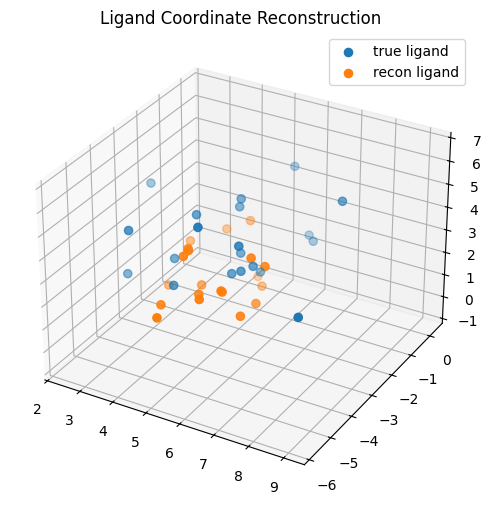

In [14]:
# Quick visualization of true vs reconstructed ligand coordinates
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

t = true_xyz.numpy()
r = recon_xyz.numpy()

ax.scatter(t[:, 0], t[:, 1], t[:, 2], label='true ligand', s=35)
ax.scatter(r[:, 0], r[:, 1], r[:, 2], label='recon ligand', s=35)
ax.set_title('Ligand Coordinate Reconstruction')
ax.legend()
plt.show()

## 5) Notes for Next Upgrade

To get even closer to the paper:
- Replace synthetic data with real protein-ligand complexes
- Add pretraining on protein-folding distance reconstruction
- Integrate protein language model embeddings (for example ESM-2)
- Use stronger atom/residue featurization and calibration metrics